In [ ]:

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import math

import scipy
import random
import statistics
import umap as UM
from scipy.stats import zscore
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
import seaborn as sns
from IPython.display import clear_output

import sys
sys.path.append('...path to ID.py...')
import ID

from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, leaves_list

In [ ]:
''' 
the single cell data to use
example used here provided in the dataset folder
'''

adata = sc.read_h5ad("...path to dataset...")


/michorlab/bingxian/miniforge3/envs/dev/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
''' 
adjust normalization according to the data
library normalization not needed if data is not provided as raw counts
'''
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata)



/michorlab/bingxian/miniforge3/envs/dev/lib/python3.13/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [5]:
pca_low = PCA(n_components = 50, random_state = 1)
reducer_init = UM.UMAP(n_neighbors=10, 
                  metric = 'euclidean', 
                  repulsion_strength=.1, 
                  n_epochs=500, 
                  negative_sample_rate=5, 
                  min_dist = .5,
                  verbose = True,
                  n_components = 2,
                  n_jobs = 10,
                  init = 'random'
                 )

reducer2 = UM.UMAP(n_neighbors=10, 
                  metric = 'euclidean', 
                  repulsion_strength=.1, 
                  n_epochs=500, 
                  negative_sample_rate=5, 
                  min_dist = .5,
                  verbose = False,
                  n_components = 2,
                  random_state = 0
                 )

In [6]:
low_dim_all = reducer_init.fit_transform(pca_low.fit_transform(adata.X))

UMAP(init='random', min_dist=0.5, n_epochs=500, n_jobs=10, n_neighbors=10, repulsion_strength=0.1, verbose=True)
Sun Mar 22 11:41:32 2026 Construct fuzzy simplicial set
Sun Mar 22 11:41:32 2026 Finding Nearest Neighbors
Sun Mar 22 11:41:32 2026 Building RP forest with 21 trees
Sun Mar 22 11:41:36 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	 5  /  17
	Stopping threshold met -- exiting after 5 iterations
Sun Mar 22 11:41:43 2026 Finished Nearest Neighbor Search
Sun Mar 22 11:41:45 2026 Construct embedding


Epochs completed:   1%|            6/500 [00:01]

	completed  0  /  500 epochs


Epochs completed:  11%| █          55/500 [00:03]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  453/500 [00:21]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:23]

Sun Mar 22 11:42:08 2026 Finished embedding


In [7]:
adata.obs.columns

Index(['cell_id', 'day', 'donor', 'cell_type', 'technology'], dtype='object')

<Axes: >

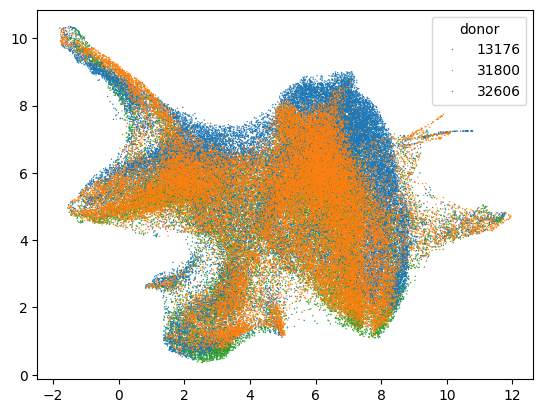

In [11]:
 sns.scatterplot(x = low_dim_all[:,0], y = low_dim_all[:,1], hue = adata.obs['donor'], palette = 'tab10',
                        linewidth = 0, s = 1, legend = True)

In [12]:
''' running ID'''
print("start")
all_data_tensor = torch.tensor(adata.X).type(torch.float32)
print(all_data_tensor.shape)
print('done')
model = ID.train_model(all_data_tensor,
                                Nnodes = 200, 
                                latent_dim = 5,
                                batchSize = 150,
                                Ndir = 50, Niter = 20000)

mag, raw, g_ebd, cell_idx = ID.get_gene_embedding_ID(model, all_data_tensor, Ntrial = 20000)

/michorlab/bingxian/miniforge3/envs/dev/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


9


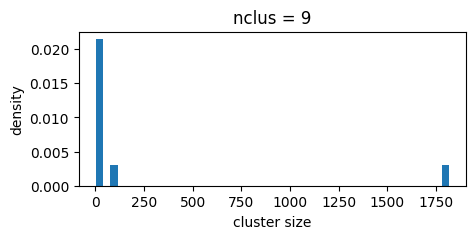

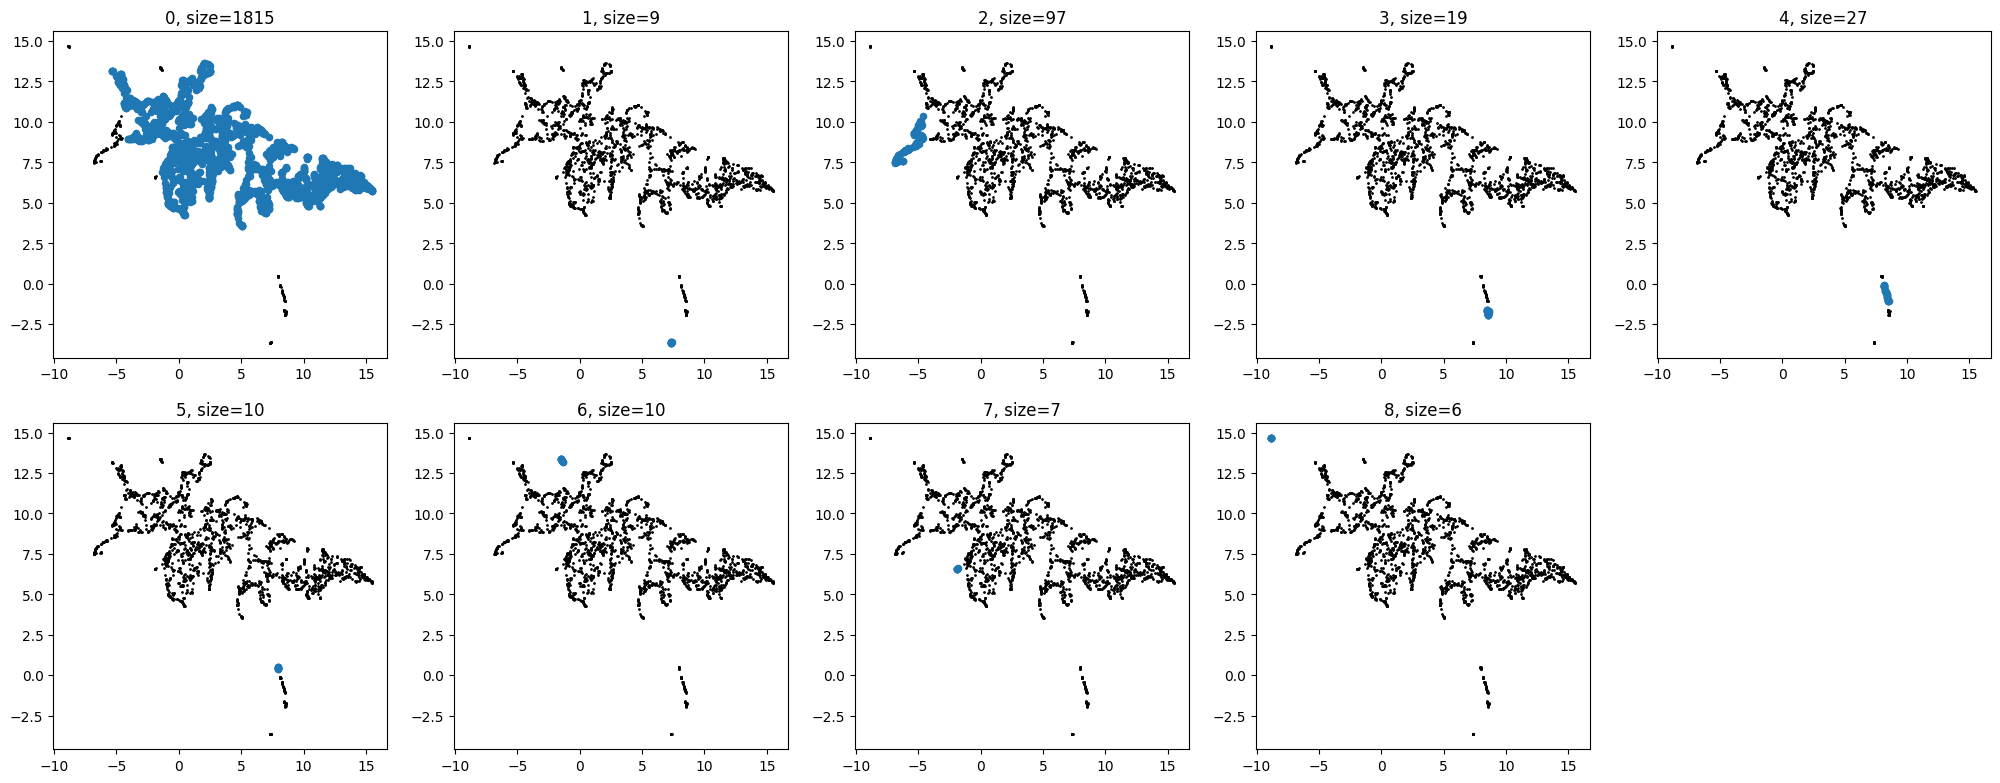

In [13]:
from sklearn.cluster import DBSCAN
gene_embedding = g_ebd.copy()

clustering = DBSCAN(eps=.5, min_samples=3).fit(gene_embedding)
# clustering.labels_.unique()
print(len(np.unique(clustering.labels_)))

unique_values, counts = np.unique(clustering.labels_, return_counts=True)
plt.hist(counts, bins = 50, density = True)
plt.gcf().set_size_inches(5,2)
plt.ylabel('density')
plt.xlabel('cluster size')
plt.title('nclus = ' + str(len(unique_values)))
plt.show()

counter = 1
for i in np.unique(clustering.labels_):
# for i in range(50):
    idx = clustering.labels_ == (i)
    plt.subplot(10,5,int(counter))
    plt.scatter(g_ebd[:,0], g_ebd[:,1], s = 1, c = 'k')
    plt.scatter(g_ebd[idx,0], g_ebd[idx,1], s = 20)
    plt.title(str(i) + ', size=' + str(idx.sum()))
    counter +=1
plt.gcf().set_size_inches(25,50)
plt.show()

In [14]:
adata.obs.columns

Index(['cell_id', 'day', 'donor', 'cell_type', 'technology'], dtype='object')

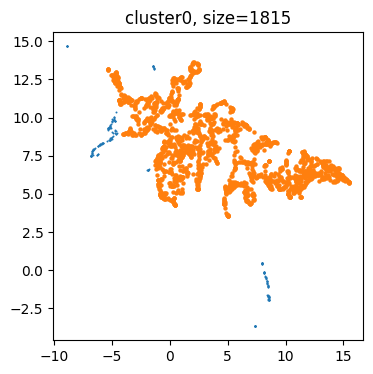

0
UMAP(init='random', min_dist=0.5, n_epochs=500, n_jobs=10, n_neighbors=10, repulsion_strength=0.1, verbose=True)
Sun Mar 22 11:48:22 2026 Construct fuzzy simplicial set
Sun Mar 22 11:48:22 2026 Finding Nearest Neighbors
Sun Mar 22 11:48:22 2026 Building RP forest with 21 trees
Sun Mar 22 11:48:22 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	Stopping threshold met -- exiting after 2 iterations
Sun Mar 22 11:48:25 2026 Finished Nearest Neighbor Search
Sun Mar 22 11:48:25 2026 Construct embedding


Epochs completed:   1%|            5/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  11%| █          54/500 [00:01]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  456/500 [00:17]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:18]


Sun Mar 22 11:48:45 2026 Finished embedding


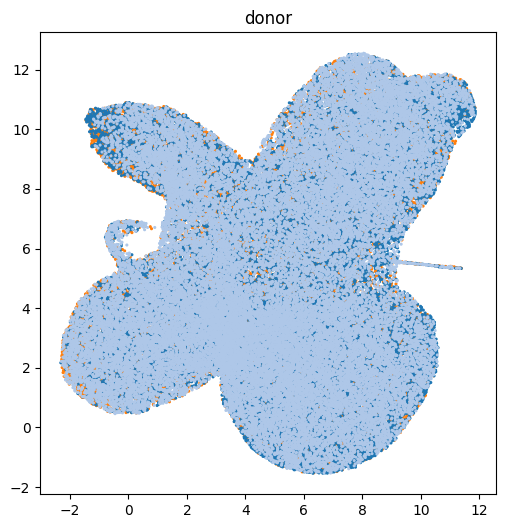

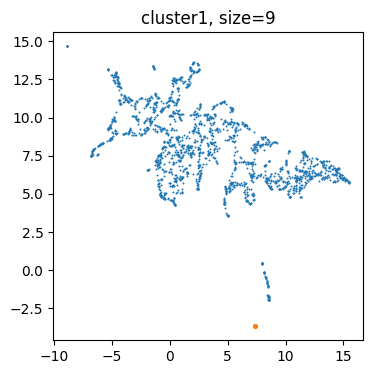

1
UMAP(init='random', min_dist=0.5, n_epochs=500, n_jobs=10, n_neighbors=10, repulsion_strength=0.1, verbose=True)
Sun Mar 22 11:48:45 2026 Construct fuzzy simplicial set
Sun Mar 22 11:48:45 2026 Finding Nearest Neighbors
Sun Mar 22 11:48:45 2026 Building RP forest with 21 trees
Sun Mar 22 11:48:46 2026 NN descent for 17 iterations
	 1  /  17
	Stopping threshold met -- exiting after 1 iterations
Sun Mar 22 11:48:47 2026 Finished Nearest Neighbor Search
Sun Mar 22 11:48:48 2026 Construct embedding


Epochs completed:   1%|            3/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  11%| █          53/500 [00:04]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  453/500 [00:37]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:41]


Sun Mar 22 11:49:30 2026 Finished embedding


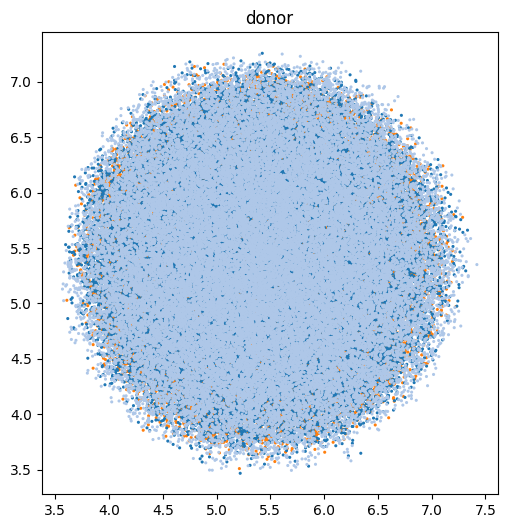

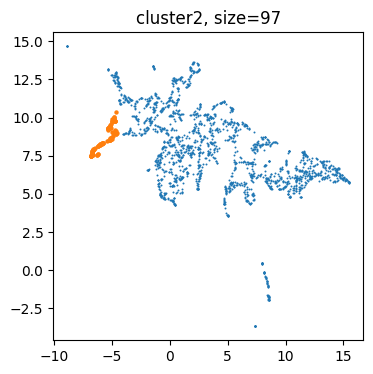

2
UMAP(init='random', min_dist=0.5, n_epochs=500, n_jobs=10, n_neighbors=10, repulsion_strength=0.1, verbose=True)
Sun Mar 22 11:49:31 2026 Construct fuzzy simplicial set
Sun Mar 22 11:49:31 2026 Finding Nearest Neighbors
Sun Mar 22 11:49:31 2026 Building RP forest with 21 trees
Sun Mar 22 11:49:31 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	Stopping threshold met -- exiting after 2 iterations
Sun Mar 22 11:49:34 2026 Finished Nearest Neighbor Search
Sun Mar 22 11:49:34 2026 Construct embedding


Epochs completed:   1%|            4/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  11%| █          53/500 [00:02]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  453/500 [00:23]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:25]


Sun Mar 22 11:50:00 2026 Finished embedding


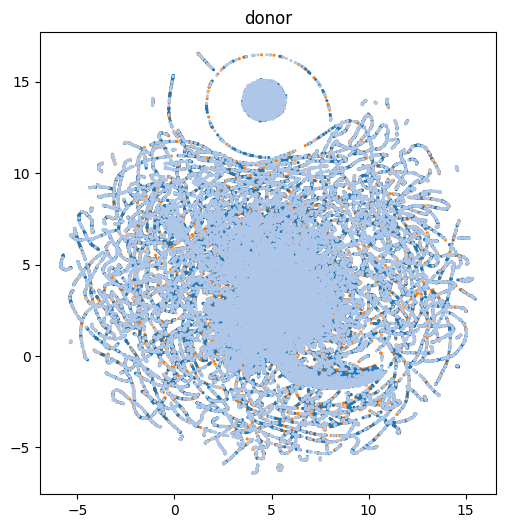

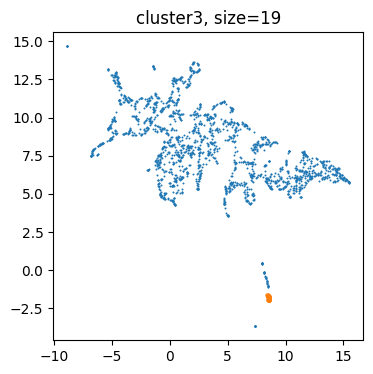

3
UMAP(init='random', min_dist=0.5, n_epochs=500, n_jobs=10, n_neighbors=10, repulsion_strength=0.1, verbose=True)
Sun Mar 22 11:50:01 2026 Construct fuzzy simplicial set
Sun Mar 22 11:50:01 2026 Finding Nearest Neighbors
Sun Mar 22 11:50:01 2026 Building RP forest with 21 trees
Sun Mar 22 11:50:01 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	Stopping threshold met -- exiting after 2 iterations
Sun Mar 22 11:50:02 2026 Finished Nearest Neighbor Search
Sun Mar 22 11:50:03 2026 Construct embedding


Epochs completed:   1%|            3/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  11%| █          53/500 [00:04]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  453/500 [00:36]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:40]


Sun Mar 22 11:50:44 2026 Finished embedding


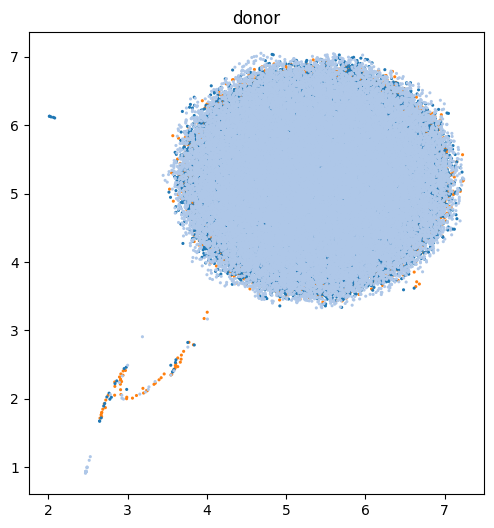

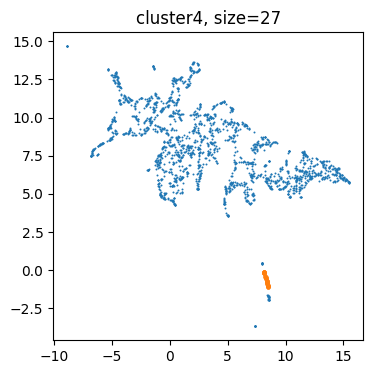

4
UMAP(init='random', min_dist=0.5, n_epochs=500, n_jobs=10, n_neighbors=10, repulsion_strength=0.1, verbose=True)
Sun Mar 22 11:50:44 2026 Construct fuzzy simplicial set
Sun Mar 22 11:50:44 2026 Finding Nearest Neighbors
Sun Mar 22 11:50:44 2026 Building RP forest with 21 trees
Sun Mar 22 11:50:45 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	Stopping threshold met -- exiting after 4 iterations
Sun Mar 22 11:50:47 2026 Finished Nearest Neighbor Search
Sun Mar 22 11:50:47 2026 Construct embedding


Epochs completed:   1%|            3/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  11%| █          53/500 [00:04]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  453/500 [00:37]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:41]


Sun Mar 22 11:51:29 2026 Finished embedding


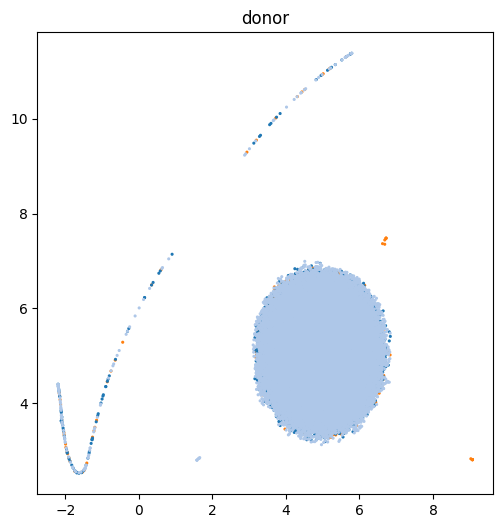

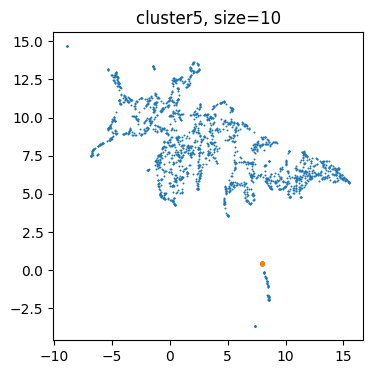

5
UMAP(init='random', min_dist=0.5, n_epochs=500, n_jobs=10, n_neighbors=10, repulsion_strength=0.1, verbose=True)
Sun Mar 22 11:51:30 2026 Construct fuzzy simplicial set
Sun Mar 22 11:51:30 2026 Finding Nearest Neighbors
Sun Mar 22 11:51:30 2026 Building RP forest with 21 trees
Sun Mar 22 11:51:30 2026 NN descent for 17 iterations
	 1  /  17
	Stopping threshold met -- exiting after 1 iterations
Sun Mar 22 11:51:32 2026 Finished Nearest Neighbor Search
Sun Mar 22 11:51:32 2026 Construct embedding


Epochs completed:   1%|            3/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  11%| █          53/500 [00:04]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  453/500 [00:37]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:41]


Sun Mar 22 11:52:14 2026 Finished embedding


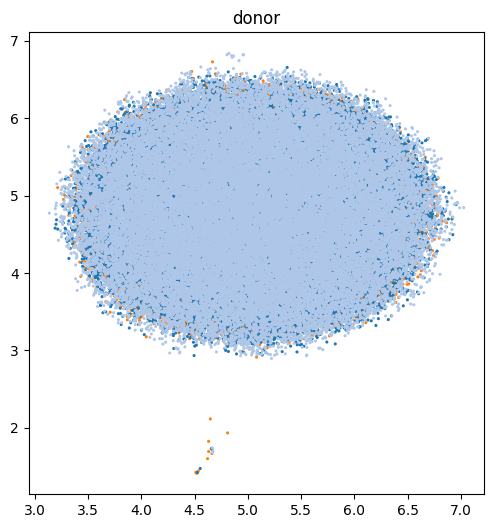

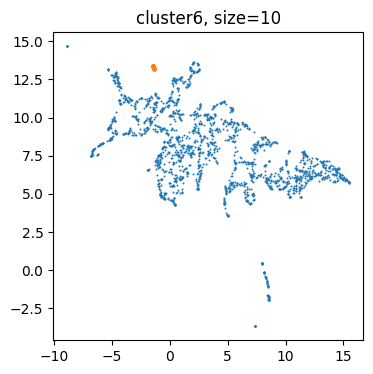

6
UMAP(init='random', min_dist=0.5, n_epochs=500, n_jobs=10, n_neighbors=10, repulsion_strength=0.1, verbose=True)
Sun Mar 22 11:52:15 2026 Construct fuzzy simplicial set
Sun Mar 22 11:52:15 2026 Finding Nearest Neighbors
Sun Mar 22 11:52:15 2026 Building RP forest with 21 trees
Sun Mar 22 11:52:15 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	Stopping threshold met -- exiting after 2 iterations
Sun Mar 22 11:52:17 2026 Finished Nearest Neighbor Search
Sun Mar 22 11:52:17 2026 Construct embedding


Epochs completed:   1%|            6/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  11%| █          54/500 [00:01]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  456/500 [00:17]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:19]


Sun Mar 22 11:52:37 2026 Finished embedding


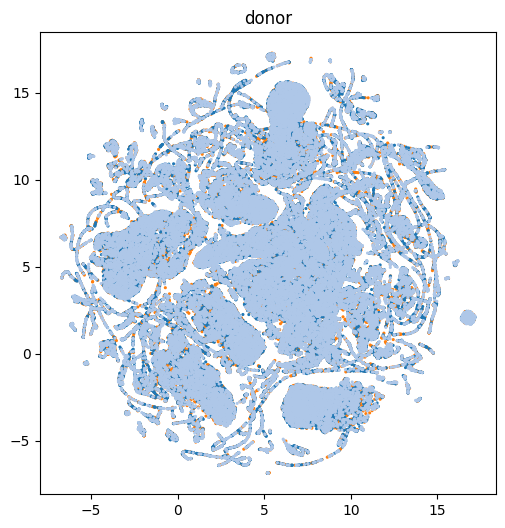

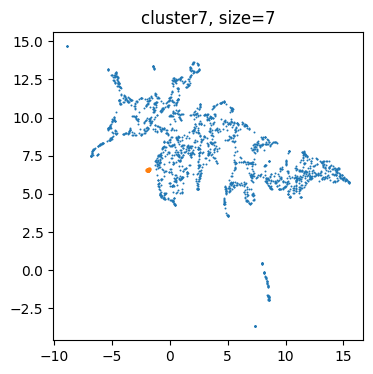

7
UMAP(init='random', min_dist=0.5, n_epochs=500, n_jobs=10, n_neighbors=10, repulsion_strength=0.1, verbose=True)
Sun Mar 22 11:52:37 2026 Construct fuzzy simplicial set
Sun Mar 22 11:52:37 2026 Finding Nearest Neighbors
Sun Mar 22 11:52:37 2026 Building RP forest with 21 trees
Sun Mar 22 11:52:38 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	Stopping threshold met -- exiting after 2 iterations
Sun Mar 22 11:52:40 2026 Finished Nearest Neighbor Search
Sun Mar 22 11:52:40 2026 Construct embedding


Epochs completed:   1%|            4/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  11%| █          53/500 [00:02]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  455/500 [00:19]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:21]


Sun Mar 22 11:53:02 2026 Finished embedding


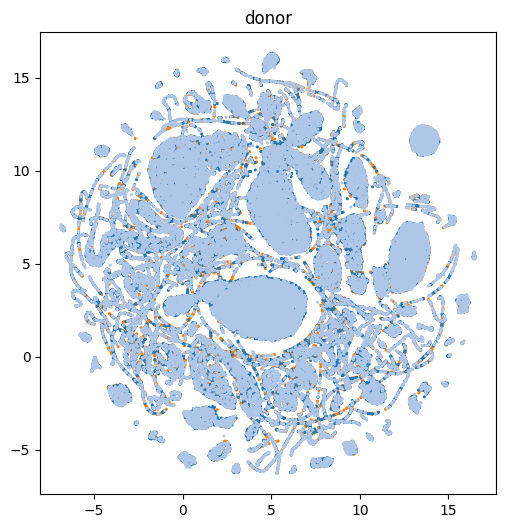

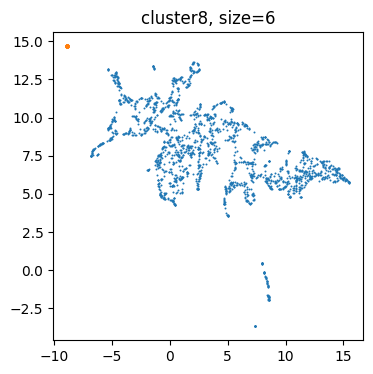

8
UMAP(init='random', min_dist=0.5, n_epochs=500, n_jobs=10, n_neighbors=10, repulsion_strength=0.1, verbose=True)
Sun Mar 22 11:53:03 2026 Construct fuzzy simplicial set
Sun Mar 22 11:53:03 2026 Finding Nearest Neighbors
Sun Mar 22 11:53:03 2026 Building RP forest with 21 trees
Sun Mar 22 11:53:03 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	Stopping threshold met -- exiting after 2 iterations
Sun Mar 22 11:53:05 2026 Finished Nearest Neighbor Search
Sun Mar 22 11:53:06 2026 Construct embedding


Epochs completed:   1%|            5/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  11%| █          54/500 [00:01]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  456/500 [00:16]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:18]


Sun Mar 22 11:53:24 2026 Finished embedding


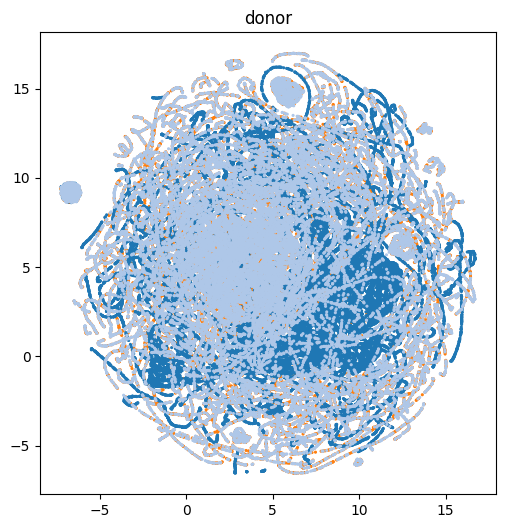

In [16]:
all_cols = adata.obs.columns[[2]]#[[1,3,4]]#[4:]

pca_low_here = PCA(n_components = 5, random_state = 1)

for i in np.unique(clustering.labels_):
    # i = 4
    idx = (clustering.labels_ == i) 
    sns.scatterplot(x = g_ebd[:,0], y = g_ebd[:,1], linewidth = 0, s = 2)
    sns.scatterplot(x = g_ebd[idx,0], y = g_ebd[idx,1], linewidth = 0, s = 10)
    plt.title('cluster' + str(i) + ', size=' + str(idx.sum()))
    plt.gcf().set_size_inches(4,4)

    plt.show()

    if idx.sum() > pca_low_here.n_components * 1:
        print(i)
        low_dim = reducer_init.fit_transform(pca_low_here.fit_transform(all_data_tensor.detach().numpy()[:, idx])) 

        for j in range(all_cols.shape[0]):
            plt.subplot(1,3,int(j + 1))
            sns.scatterplot(x = low_dim[:,0], y = low_dim[:,1], linewidth = 0, hue = adata.obs[all_cols[j]].values, palette = 'tab20', legend = False, s  = 5)
            plt.title(all_cols[j])
            plt.gcf().set_size_inches(20,6)
        
        plt.show()

cluster 8 here is the reason why different donors appear to be batch effected

In [18]:
new_data = all_data_tensor[:,clustering.labels_ != 8].detach().numpy()
new_umap = reducer_init.fit_transform(pca_low.fit_transform(new_data))

UMAP(init='random', min_dist=0.5, n_epochs=500, n_jobs=10, n_neighbors=10, repulsion_strength=0.1, verbose=True)
Sun Mar 22 11:58:36 2026 Construct fuzzy simplicial set
Sun Mar 22 11:58:36 2026 Finding Nearest Neighbors
Sun Mar 22 11:58:36 2026 Building RP forest with 21 trees
Sun Mar 22 11:58:36 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	 5  /  17
	Stopping threshold met -- exiting after 5 iterations
Sun Mar 22 11:58:39 2026 Finished Nearest Neighbor Search
Sun Mar 22 11:58:39 2026 Construct embedding


Epochs completed:   1%|            5/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  11%| █          55/500 [00:02]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  453/500 [00:20]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:23]

Sun Mar 22 11:59:03 2026 Finished embedding


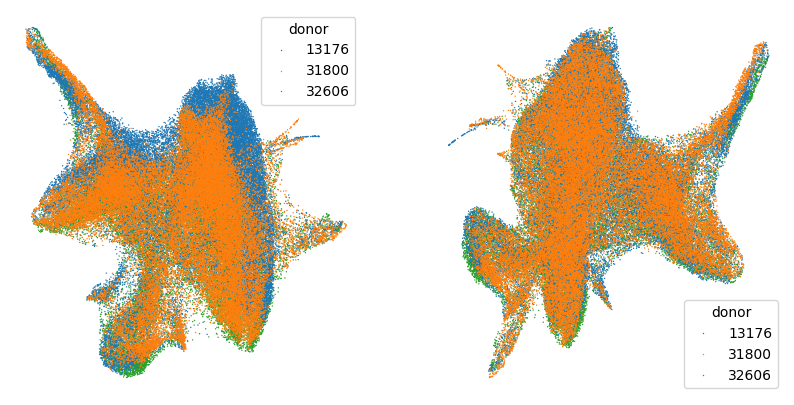

In [21]:
plt.subplot(1,2,1)
sns.scatterplot(x = low_dim_all[:,0], y = low_dim_all[:,1], hue = adata.obs['donor'], palette = 'tab10',
                        linewidth = 0, s = 1, legend = True)
plt.axis('off')


plt.subplot(1,2,2)
sns.scatterplot(x = new_umap[:,0], y = new_umap[:,1], hue = adata.obs['donor'], palette = 'tab10',
                        linewidth = 0, s = 1, legend = True)
plt.axis('off')

plt.gcf().set_size_inches(10,5)